## Data-driven modelling of cooperative decision-making under resource inequality in an urban collective-risk dilemma
#### Emergent dynamics from agent-based hybrid model
 - $H_0$: Probability of the next contribution based on the previous one.
 - $H_1$: Probability of the next contribution based on the previous average contribution of others.
 - $H_2$: Probability of the next contribution based on the Cumulative contribution of all players.
 - $H_3$: Probability of the next contribution based on the remaining relative coins.

In [1]:
#Register some PC Stats
%load_ext watermark
%watermark

Last updated: 2026-04-28T14:31:58.679265+02:00

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 124 Stepping 0, AuthenticAMD
CPU cores   : 12
Architecture: 64bit



In [2]:
#Importing all libraries needed
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib import cm
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from collections import defaultdict
from matplotlib.cm import ScalarMappable
from matplotlib import colors
from functions import *
import os
import pickle
# Set Pandas to display all columns
pd.set_option('display.max_columns', None)
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
%matplotlib inline

In [3]:
# Load Probabilties datasets
datasets = {
    "H0": pd.read_csv("Datasets/H0_Previous_contribution.csv"),
    "H1": pd.read_csv("Datasets/H1_Others_contribution.csv"),
    "H2": pd.read_csv("Datasets/H2_Cumulative_contribution.csv"),
    "H3": pd.read_csv("Datasets/H3_Spending_coins.csv")
}
# Load Experimental datasets for comparision
df_users = pd.read_csv("Datasets/df_users_six_players.csv")
successful_users_six = pd.read_csv("Datasets/successful_users_six.csv")

In [4]:
hypothesis = "Hybridisation"

In [5]:
# Ensure the folder exists
output_folder = f"Figures/{hypothesis}/"
os.makedirs(output_folder, exist_ok=True)

#### Simulations for agent-based hybrid model (DON'T RUN IF YOU DON'T CHANGE ANYTHING!)

In [ ]:
%%time
# Create a fixed random generator instance
SEED = 42  # Set a fixed seed
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
df_sim_seg, Hybridisation_counter, counters_successful, counters_unsuccessful = simulate_games_dataframe_hybrid(datasets, hypothesis, rng)

Wall time: 6h 53min 37s


In [7]:
counters_successful_clean = convert_defaultdict_to_dict(counters_successful)
counters_unsuccessful_clean = convert_defaultdict_to_dict(counters_unsuccessful)

In [18]:
with open("Datasets/counters_successful10000.pkl", "wb") as f:
    pickle.dump(counters_successful_clean, f)

with open("Datasets/counters_unsuccessful10000.pkl", "wb") as f:
    pickle.dump(counters_unsuccessful_clean, f)

In [ ]:
df_sim_seg.to_csv("Datasets/df_users_hybrid_sim.csv", index=False)

Reading Simulations for agent-based hybrid model previously done

In [6]:
with open("Datasets/counters_successful10000.pkl", "rb") as f:
    counters_successful = pickle.load(f)

with open("Datasets/counters_unsuccessful10000.pkl", "rb") as f:
    counters_unsuccessful = pickle.load(f)

In [7]:
df_sim_seg = pd.read_csv("Datasets/df_users_hybrid_sim.csv")

### Proportion of games reaching the collective goal
Goal attainment for large number of games in hybrid model

In [17]:
successful = df_sim_seg[df_sim_seg["goal_reached"] == 1].copy()
unsuccessful = df_sim_seg[df_sim_seg["goal_reached"] == 0].copy()

In [18]:
total_games = df_sim_seg.groupby("control_wealth")["partida_id"].nunique()
successful_games = successful.groupby("control_wealth")["partida_id"].nunique()
unsuccessful_games = unsuccessful.groupby("control_wealth")["partida_id"].nunique()

proportion_ci_results = {}
for cw in total_games.index:
    total = total_games.get(cw, 0)
    success = successful_games.get(cw, 0)
    prop = success / total if total > 0 else 0
    ci_low, ci_high = compute_wilson_ci(success, total)
    proportion_ci_results[cw] = f"{prop:.3f} [{ci_low:.2f}, {ci_high:.2f}]"

# Summary table with Wilson CI proportions
summary_table = pd.DataFrame({
    "Wealth treatment": total_games.index,
    "Total games": total_games.values,
    "Successful games": successful_games.reindex(total_games.index, fill_value=0).values,
    "Unsuccessful games": unsuccessful_games.reindex(total_games.index, fill_value=0).values,
    "Success rate [95\\% CI]": [proportion_ci_results[cw] for cw in total_games.index]
})

#Reorder for readability
summary_table = summary_table[["Wealth treatment", "Total games", "Successful games", "Unsuccessful games", "Success rate [95\\% CI]"]]
summary_table.reset_index(drop=True, inplace=True)
# Generate LaTeX
latex_summary_table = summary_table.to_latex(index=False, caption="Proportion of Successful Games per Game Type (with Wilson CI)", label="tab:success_prop", column_format="ccccc", escape=False)
print(latex_summary_table)

\begin{table}
\caption{Proportion of Successful Games per Game Type (with Wilson CI)}
\label{tab:success_prop}
\begin{tabular}{ccccc}
\toprule
Wealth treatment & Total games & Successful games & Unsuccessful games & Success rate [95\% CI] \\
\midrule
EQUAL & 10000 & 9699 & 301 & 0.970 [0.97, 0.97] \\
UNEQUAL-H & 10000 & 9667 & 333 & 0.967 [0.96, 0.97] \\
UNEQUAL-L & 10000 & 8828 & 1172 & 0.883 [0.88, 0.89] \\
\bottomrule
\end{tabular}
\end{table}



Number of players by initial endowment under the hybrid model

In [22]:
total_users = df_sim_seg.groupby("endowment_initial")["partida_id"].count()
successful_users = successful.groupby("endowment_initial")["partida_id"].count()
unsuccessful_users = unsuccessful.groupby("endowment_initial")["partida_id"].count()

# Summary table with Wilson CI proportions
summary_table = pd.DataFrame({
    "Endowment": total_users.index,
    "Total users": total_users.values,
    "Successful users": successful_users.reindex(total_users.index, fill_value=0).values,
    "Unsuccessful users": unsuccessful_users.reindex(total_users.index, fill_value=0).values
})

#Add success rate
summary_table["Success rate [95\\% CI]"] = (summary_table["Successful users"] / summary_table["Total users"]).round(3)
#Reorder for readability
summary_table = summary_table[["Endowment", "Total users", "Successful users", "Unsuccessful users", "Success rate [95\\% CI]"]]
summary_table.reset_index(drop=True, inplace=True)
# Generate LaTeX
latex_summary_table = summary_table.to_latex(index=False, caption="Proportion of Successful Games per Game Type (with Wilson CI)", label="tab:success_prop", column_format="ccccc", escape=False)
print(latex_summary_table)

\begin{table}
\caption{Proportion of Successful Games per Game Type (with Wilson CI)}
\label{tab:success_prop}
\begin{tabular}{ccccc}
\toprule
Endowment & Total users & Successful users & Unsuccessful users & Success rate [95\% CI] \\
\midrule
24 & 20000 & 17656 & 2344 & 0.883000 \\
30 & 40000 & 38668 & 1332 & 0.967000 \\
40 & 60000 & 58194 & 1806 & 0.970000 \\
48 & 40000 & 35312 & 4688 & 0.883000 \\
60 & 20000 & 19334 & 666 & 0.967000 \\
\bottomrule
\end{tabular}
\end{table}



### Dominant decision strategies

Selected contributions by dominant internal strategies

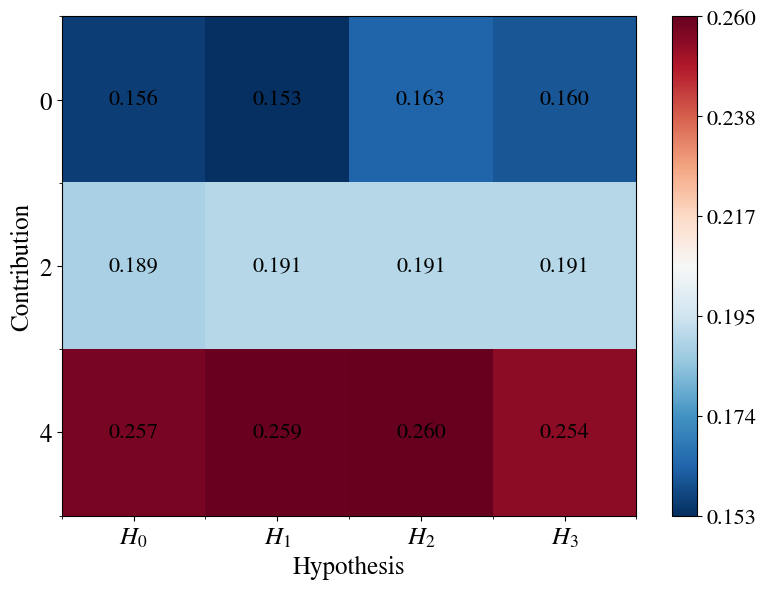

In [ ]:
# Mock structure for counters_successful["winning_hypothesis_counter"] to proceed with plotting
# Structure: counters_successful["winning_hypothesis_counter"][endowment][round][hypothesis][contribution] = count

# Aggregate over all endowments and rounds
aggregated = pd.DataFrame(0, index=[0, 2, 4], columns=["H0", "H1", "H2", "H3"])
whc = counters_successful["winning_hypothesis_counter"]

for endowment_data in whc.values():
    for round_data in endowment_data.values():
        for hyp, contrib_counts in round_data.items():
            for contrib, count in contrib_counts.items():
                aggregated.at[contrib, hyp] += count

# Convert to long format
heatmap_data = aggregated.stack().reset_index()
heatmap_data.columns = ['contribution', 'hypothesis', 'count']

# Create pivot table for plotting
heatmap_matrix = heatmap_data.pivot(index='contribution', columns='hypothesis', values='count')
heatmap_matrix = heatmap_matrix.loc[[0, 2, 4]]  # Ensure correct order

# Normalize each column (hypothesis) so that their values sum to 1
normalized_matrix = heatmap_matrix/1522476

# Rename columns to LaTeX math format
rename_map = {f"H{i}": f"$H_{i}$" for i in range(4)}
normalized_matrix = normalized_matrix.rename(columns=rename_map)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap("RdBu_r")#YlGnBu
vmin = normalized_matrix.min().min()
vmax = normalized_matrix.max().max()

# Plot the normalized heatmap
cax = ax.imshow(normalized_matrix, cmap=cmap, aspect="auto", origin="upper",
                interpolation="nearest", vmin=vmin, vmax=vmax)

# Colorbar with fixed scale from 0 to 1
cbar = fig.colorbar(cax, ax=ax)
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_yticklabels([f"{tick:.3f}" for tick in ticks])

# Axis ticks and labels
ax.set_xticks(np.arange(len(normalized_matrix.columns)))
ax.set_xticklabels(normalized_matrix.columns, fontsize=18)
ax.set_yticks(np.arange(len(normalized_matrix.index)))
ax.set_yticklabels(normalized_matrix.index, fontsize=18)

# Grid cleanup
ax.set_xticks(np.arange(-0.5, len(normalized_matrix.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(normalized_matrix.index), 1), minor=True)
ax.grid(False, which="both")

# Annotate each cell
for i in range(len(normalized_matrix.index)):
    for j in range(len(normalized_matrix.columns)):
        value = normalized_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="black", fontsize=16)

# Labels
ax.set_xlabel("Hypothesis", fontsize=18)
ax.set_ylabel("Contribution", fontsize=18)

plt.tight_layout()
plt.savefig(f"{output_folder}/WinningContribsHypoSUCCES.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

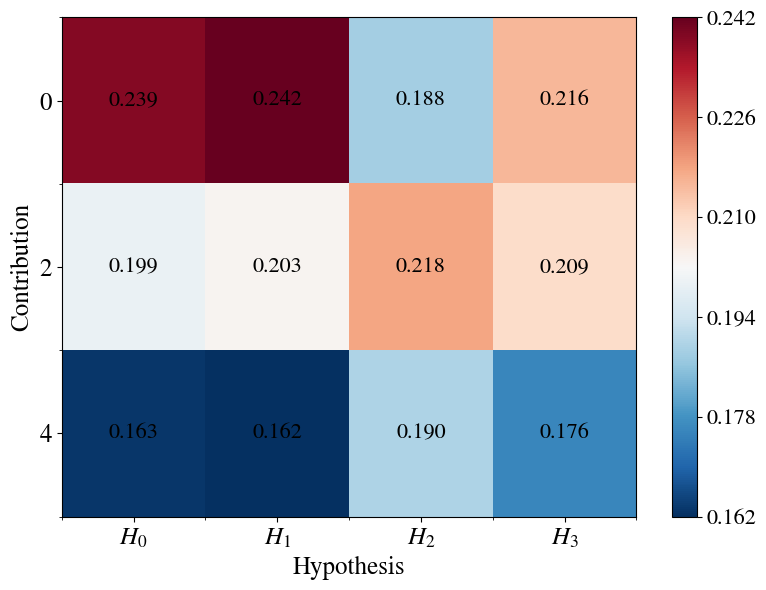

In [9]:
# Aggregate over all endowments and rounds
aggregated = pd.DataFrame(0, index=[0, 2, 4], columns=["H0", "H1", "H2", "H3"])
whc = counters_unsuccessful["winning_hypothesis_counter"]

for endowment_data in whc.values():
    for round_data in endowment_data.values():
        for hyp, contrib_counts in round_data.items():
            for contrib, count in contrib_counts.items():
                aggregated.at[contrib, hyp] += count

# Convert to long format
heatmap_data = aggregated.stack().reset_index()
heatmap_data.columns = ['contribution', 'hypothesis', 'count']

# Create pivot table for plotting
heatmap_matrix = heatmap_data.pivot(index='contribution', columns='hypothesis', values='count')
heatmap_matrix = heatmap_matrix.loc[[0, 2, 4]]  # Ensure correct order

# Normalize each column (hypothesis) so that their values sum to 1
normalized_matrix = heatmap_matrix/97524

#Rename columns to LaTeX math format
rename_map = {f"H{i}": f"$H_{i}$" for i in range(4)}
normalized_matrix = normalized_matrix.rename(columns=rename_map)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap("RdBu_r")#YlGnBu
vmin = normalized_matrix.min().min()
vmax = normalized_matrix.max().max()

# Plot the normalized heatmap
cax = ax.imshow(normalized_matrix, cmap=cmap, aspect="auto", origin="upper",
                interpolation="nearest", vmin=vmin, vmax=vmax)

# Colorbar with fixed scale from 0 to 1
cbar = fig.colorbar(cax, ax=ax)
ticks = np.linspace(vmin, vmax, 6)
cbar.set_ticks(ticks)
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_yticklabels([f"{tick:.3f}" for tick in ticks])

# Axis ticks and labels
ax.set_xticks(np.arange(len(normalized_matrix.columns)))
ax.set_xticklabels(normalized_matrix.columns, fontsize=18)
ax.set_yticks(np.arange(len(normalized_matrix.index)))
ax.set_yticklabels(normalized_matrix.index, fontsize=18)

# Grid cleanup
ax.set_xticks(np.arange(-0.5, len(normalized_matrix.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(normalized_matrix.index), 1), minor=True)
ax.grid(False, which="both")

# Annotate each cell
for i in range(len(normalized_matrix.index)):
    for j in range(len(normalized_matrix.columns)):
        value = normalized_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="black", fontsize=16)

# Labels
ax.set_xlabel("Hypothesis", fontsize=18)
ax.set_ylabel("Contribution", fontsize=18)

plt.tight_layout()
plt.savefig(f"{output_folder}/WinningContribsHypoUNSUCCES.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

Temporal evolution of selected hypotheses by contribution level in successful games

In [29]:
def plot_temporal_winning_hypotheses_normalized(counter, endowment, successful_users):
    data = []
    for round_idx, hyp_data in counter["winning_hypothesis_counter"][endowment].items():
        for hyp, contribs in hyp_data.items():
            for contrib, count in contribs.items():
                data.append((round_idx, hyp, contrib, count))
    df = pd.DataFrame(data, columns=["Round", "Hypothesis", "Contribution", "Count"])

    # Normalize count by number of successful users for this endowment
    total_successful = successful_users.get(endowment, 1)  # Avoid div-by-zero
    df["NormalizedCount"] = df["Count"] / total_successful
    df["Round"]=df["Round"]+1

    # Updated stronger colors
    hypothesis_palette = {
        "H0": "#cc66ff",  # Markov - violet
        "H1": "#ffc107",  # Altruist - yellow
        "H2": "#17cfcf",  # Target - turquoise
        "H3": "#ff5c57",  # Selfish - coral
    }
    contribution_markers = {0: "o", 2: "s", 4: "D"}

    plt.figure(figsize=(8, 6))

    for contrib in sorted(df["Contribution"].unique()):
        for hyp in df["Hypothesis"].unique():
            subset = df[(df["Hypothesis"] == hyp) & (df["Contribution"] == contrib)]
            if not subset.empty:
                label = f"{hyp}, Contrib {contrib}"
                plt.plot(subset["Round"], subset["NormalizedCount"],
                         marker=contribution_markers[contrib],
                         color=hypothesis_palette[hyp],
                         label=label,
                         alpha=0.7)

    plt.xlabel("Round", fontsize=18)
    plt.ylabel("Hypothesis selection rate", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2,11))

    # Round up to nearest 0.1
    ymax = df["NormalizedCount"].max()
    ymax_rounded = math.ceil(ymax * 10) / 10  

    # Create 5 ticks
    yticks = np.linspace(0, ymax_rounded, 5)

    # Apply limits
    plt.ylim(0, ymax_rounded)

    # Format: 0 as "0", rest as one decimal
    ytick_labels = ["0" if y == 0 else f"{y:.1f}" for y in yticks]
    plt.yticks(yticks, ytick_labels)

    plt.tight_layout()
    if counter == counters_successful:
        plt.savefig(f"{output_folder}/WinningContribsHypoRoundSUCCES_{endowment}.pdf", bbox_inches='tight', pad_inches=0.1)
    else:
        plt.savefig(f"{output_folder}/WinningContribsHypoRoundUNSUCCES_{endowment}.pdf", bbox_inches='tight', pad_inches=0.1)
    plt.show()

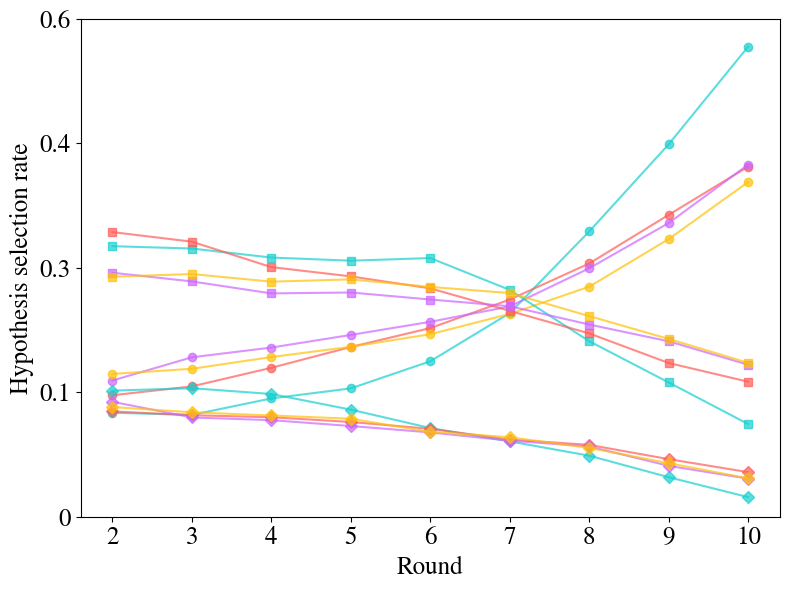

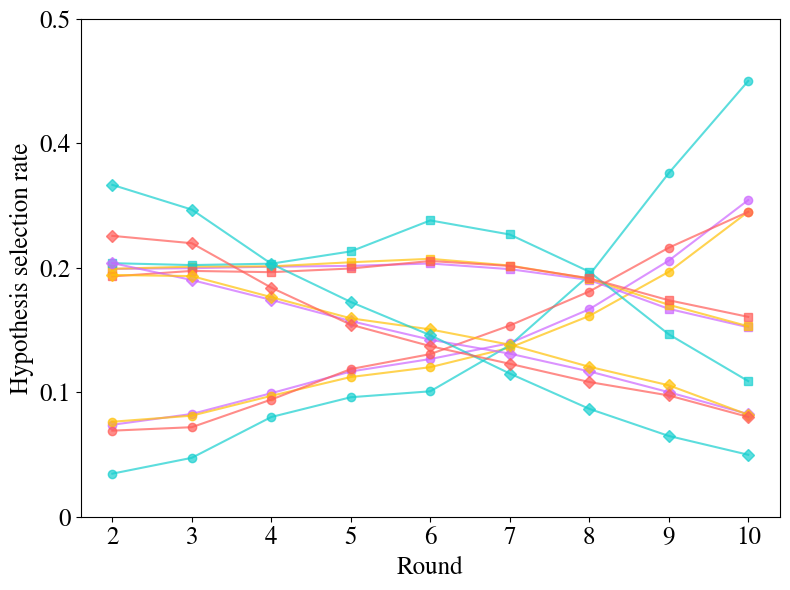

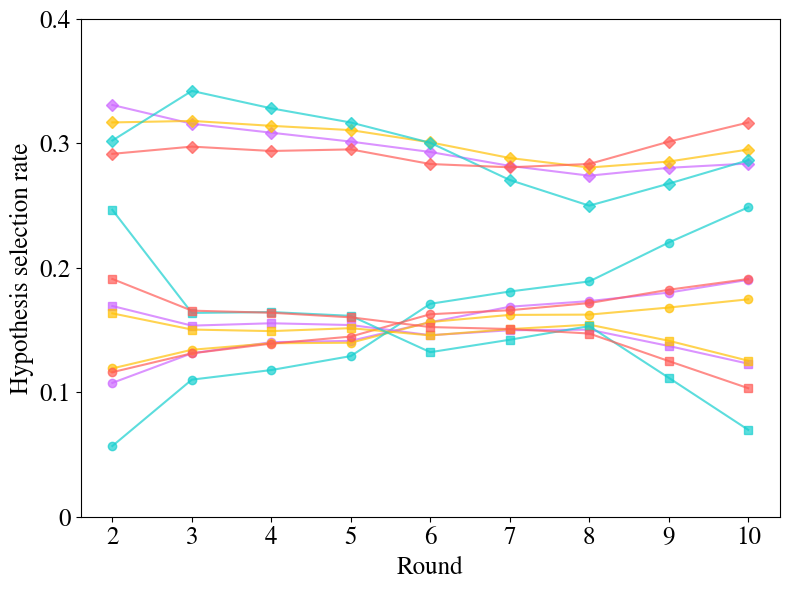

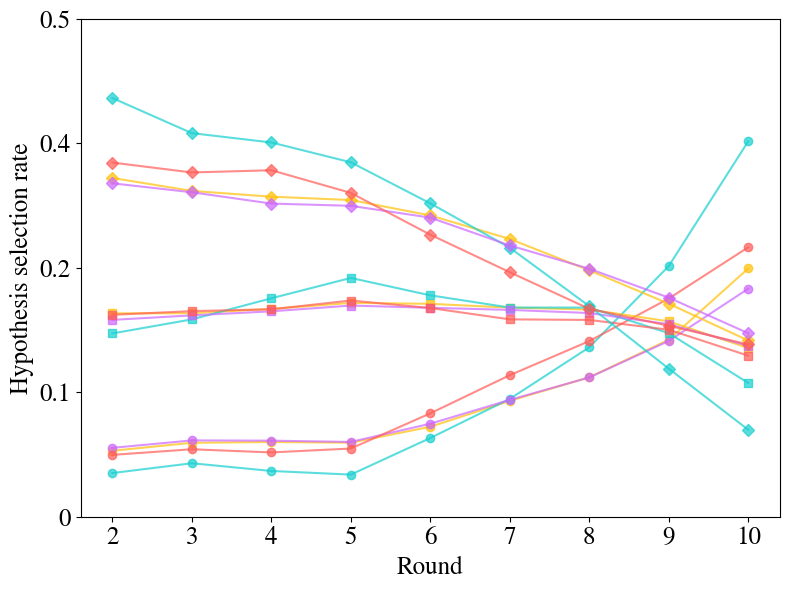

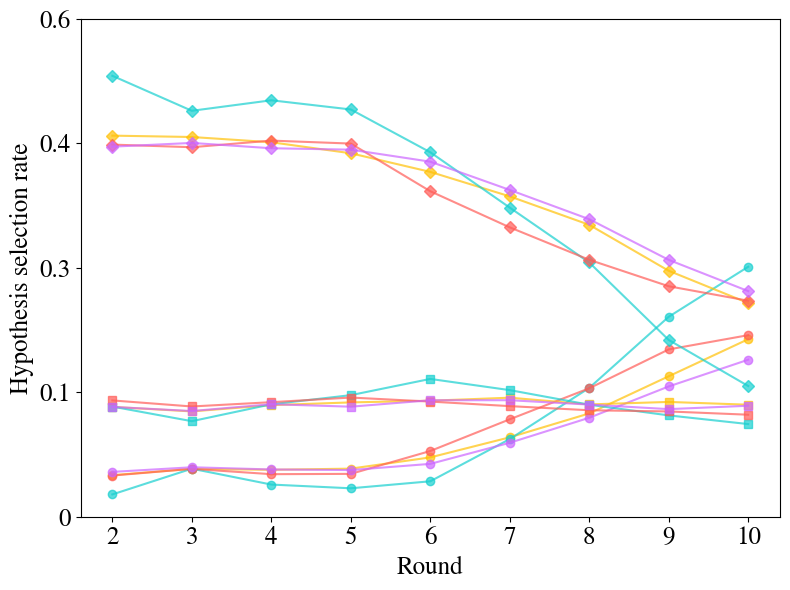

In [30]:
plot_temporal_winning_hypotheses_normalized(counters_successful, 24, successful_users)
plot_temporal_winning_hypotheses_normalized(counters_successful, 30, successful_users)
plot_temporal_winning_hypotheses_normalized(counters_successful, 40, successful_users)
plot_temporal_winning_hypotheses_normalized(counters_successful, 48, successful_users)
plot_temporal_winning_hypotheses_normalized(counters_successful, 60, successful_users)

Temporal evolution of selected hypotheses by contribution level in unsuccessful games

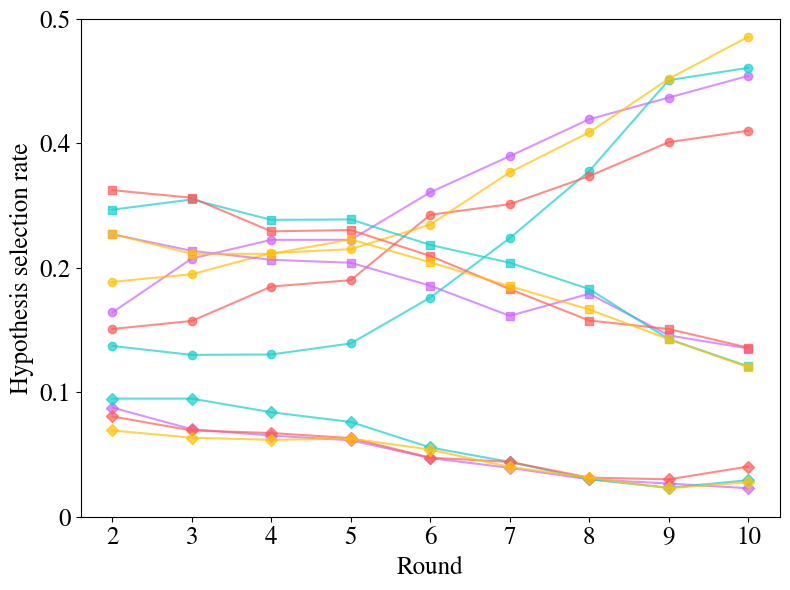

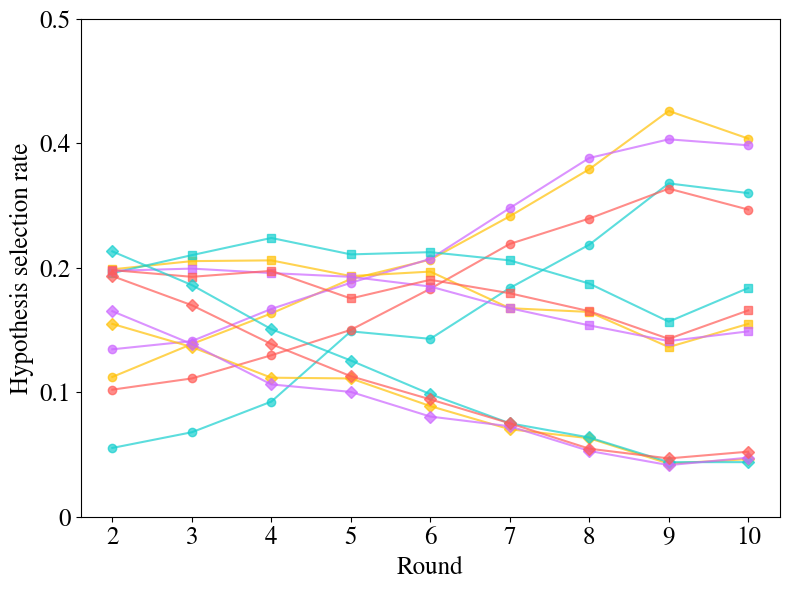

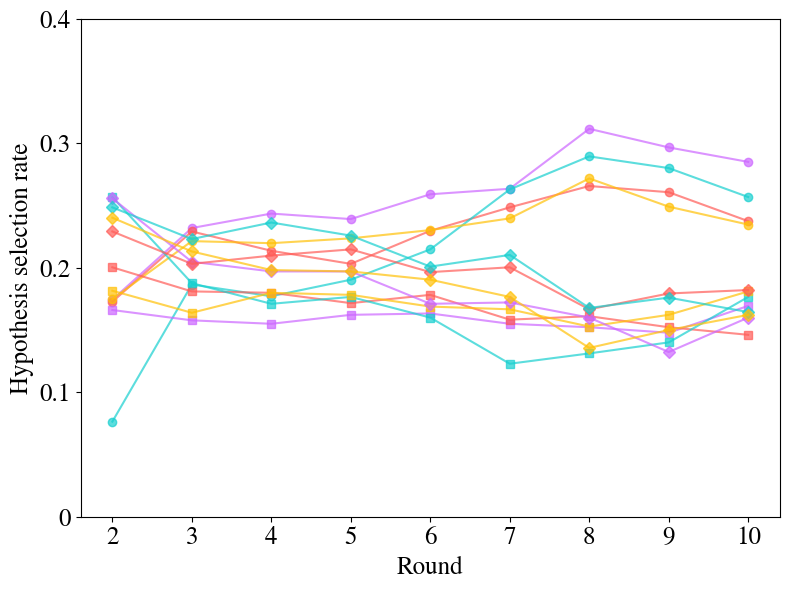

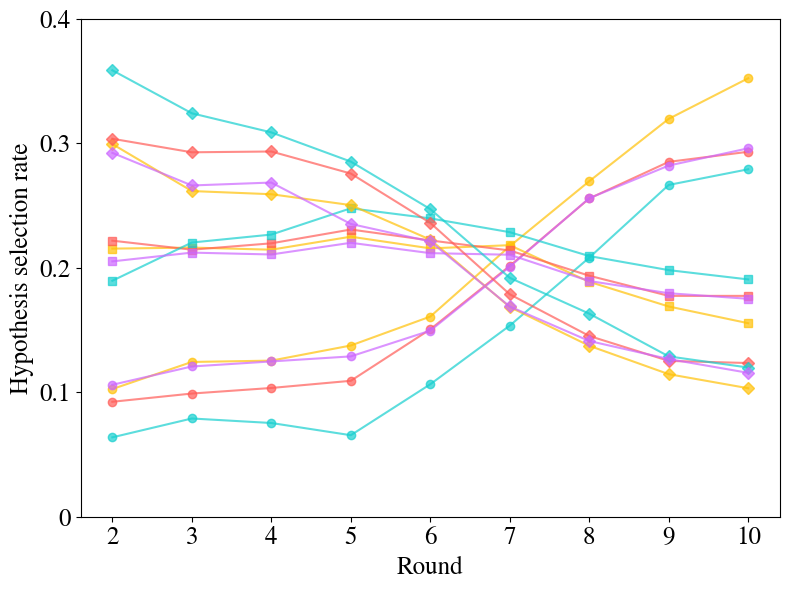

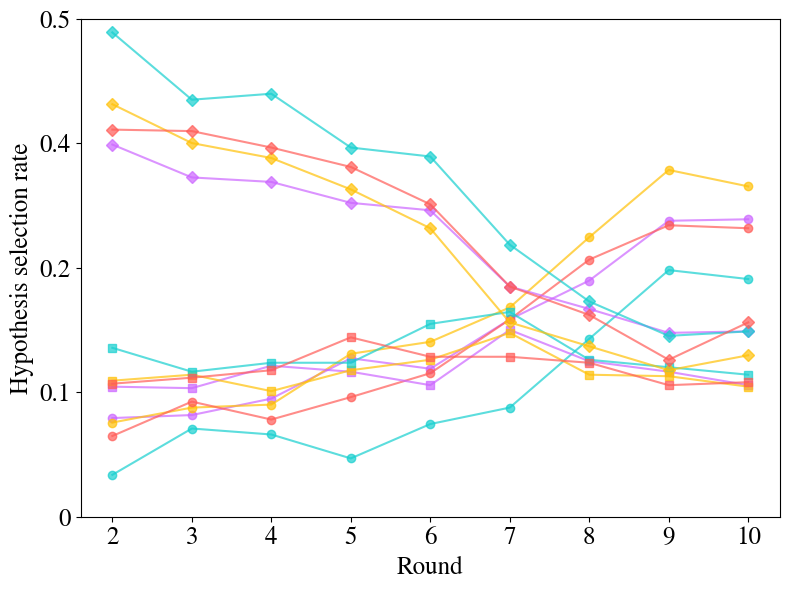

In [31]:
plot_temporal_winning_hypotheses_normalized(counters_unsuccessful, 24, unsuccessful_users)
plot_temporal_winning_hypotheses_normalized(counters_unsuccessful, 30, unsuccessful_users)
plot_temporal_winning_hypotheses_normalized(counters_unsuccessful, 40, unsuccessful_users)
plot_temporal_winning_hypotheses_normalized(counters_unsuccessful, 48, unsuccessful_users)
plot_temporal_winning_hypotheses_normalized(counters_unsuccessful, 60, unsuccessful_users)

### Evolution of decision vector patterns

In [ ]:
ALPHABET = (0, 2, 4)    
ROUND_LENGTH = 4
HYP_KEYS = ("H0", "H1", "H2", "H3")

def counts_from_vector(vec, alphabet=ALPHABET):
    cnt = {v: 0 for v in alphabet}
    for x in vec:
        if x not in cnt:
            raise ValueError(f"Value {x} is not in the alphabet {alphabet}")
        cnt[x] += 1
    return tuple(cnt[v] for v in alphabet)

def entropy_from_counts(counts, base=math.e):
    n = sum(counts)
    if n == 0:
        return 0.0
    H = 0.0
    for c in counts:
        if c > 0:
            p = c / n
            H -= p * math.log(p, base)
    return H

def max_reachable_entropy(n=4, K=3, base=math.e):
    """
    Maximum *reachable* entropy for a vector of length n with K categories
    with probabilities restricted to multiples of 1/n (as in this case).
    """
    best = 0.0
    def gen_counts(total, buckets, prefix=()):
        if buckets == 1:
            yield prefix + (total,)
        else:
            for x in range(total + 1):
                yield from gen_counts(total - x, buckets - 1, prefix + (x,))
    for counts in gen_counts(n, K):
        H = entropy_from_counts(counts, base=base)
        if H > best:
            best = H
    return best

# Precompute (n=4, K=3)
H_MAX_REAL = max_reachable_entropy(n=ROUND_LENGTH, K=len(ALPHABET), base=math.e)  # ~1.0397207708

def plurality_margin_and_ambiguity(counts, n=ROUND_LENGTH):
    s = sorted(counts, reverse=True)
    M = (s[0] - s[1]) / n
    A = 1.0 - M
    return M, A

def metrics_for_vector(vec, alphabet=(0, 2, 4)):
    """
    vec: iterable of long 4, i.e. [4,2,0,2]
    Return dict with:
      - counts, k
      - H, H_norm_real
      - M, A
      - mean, std, R, G_norm
      - mu_dec, var_dec_norm, tied_vals
      - pattern_id (1–4)
    """
    if len(vec) != 4:
        raise ValueError(f"Wrong length {len(vec)}")

    # Counts and entropy
    counts = counts_from_vector(vec, alphabet=alphabet)
    k = sum(1 for c in counts if c > 0)
    H = entropy_from_counts(counts, base=math.e)
    H_norm_real = (H / H_MAX_REAL) if H_MAX_REAL > 0 else 0.0
    M, A = plurality_margin_and_ambiguity(counts, n=4)

    # Mean and real dispersion
    vec = np.asarray(vec, dtype=float)
    mean = float(np.mean(vec))
    std = float(np.std(vec, ddof=0))  # Standard deviation (no normalization)
    R = (float(np.max(vec)) - float(np.min(vec))) / 4.0

    # Gini mean difference
    diffs = [abs(vec[i] - vec[j]) for i in range(len(vec)) for j in range(i+1, len(vec))]
    G = float(np.mean(diffs)) if diffs else 0.0
    G_norm = G / 4.0

    # Plurality and expected decision
    vals, counts_arr = np.unique(vec, return_counts=True)
    maxc = counts_arr.max()
    tied_vals = vals[counts_arr == maxc]
    mu_dec = float(np.mean(tied_vals))
    var_dec_norm = float(np.var(tied_vals, ddof=0)) / 4.0 if len(tied_vals) > 1 else 0.0

    # Clasification of the pattern
    counts_sorted = sorted(counts_arr, reverse=True)
    if counts_sorted == [4]:
        pattern_id = 4  # 4 equal
    elif counts_sorted == [3, 1]:
        pattern_id = 3  # 3+1
    elif counts_sorted == [2, 2]:
        pattern_id = 2  # 2+2
    else:
        pattern_id = 1  # 2+1+1

    return {
        "vector": tuple(vec.tolist()),
        "counts": counts,
        "k": k,
        "H": float(H),
        "H_norm_real": float(H_norm_real),
        "M": float(M),
        "A": float(A),
        "mean": mean,
        "std": std,
        "R": R,
        "G_norm": G_norm,
        "mu_dec": mu_dec,
        "var_dec_norm": var_dec_norm,
        "pattern_id": pattern_id,
        "tied_vals": tied_vals.tolist(),
    }

# ---------------------------
# Results table
# ---------------------------
def build_results_dataframe(counters_successful,
                            branch="contribution_variability",
                            rounds_range=None,
                            endowments=None):
    """

    Parameters
    ----------
    counters_successful : dict-like
    branch : str
    rounds_range : iterable o None
    endowments : iterable o None

    Returns
    -------
    df : pandas.DataFrame
        Columns: endowment, round, player_id, H, H_norm_real, M, A, vector, counts
    """
    store = []
    cv = counters_successful[branch]  # dict: endowment -> round_idx -> {H0,H1,H2,H3} -> list per player
    ends = endowments if endowments is not None else list(cv.keys())

    for endow in ends:
        if endow not in cv:
            continue
        rounds_dict = cv[endow]
        round_keys = rounds_range if rounds_range is not None else list(rounds_dict.keys())

        for rnd in round_keys:
            hyp_data = rounds_dict.get(rnd, {})
            if not hyp_data:
                continue
            # Prove H0..H3 and maximum long
            if any(h not in hyp_data for h in HYP_KEYS):
                continue
            lengths = [len(hyp_data[h]) for h in HYP_KEYS]
            n_players = min(lengths) if lengths else 0
            if n_players == 0:
                continue

            for player_id in range(n_players):
                try:
                    vec = [hyp_data[h][player_id] for h in HYP_KEYS]
                except Exception:
                    continue
                if any(v not in ALPHABET for v in vec):
                    continue
                m = metrics_for_vector(vec)
                store.append({
                    "endowment": endow,
                    "round": rnd,
                    "player_id": player_id,
                    **m
                })

    df = pd.DataFrame(store)

    if not df.empty:
        df.sort_values(["endowment", "round", "player_id"], inplace=True)
        df.reset_index(drop=True, inplace=True)
    return df

Generating dataframes of Patterns for counters_successful and counters_unsuccessful

In [42]:
%%time
df = build_results_dataframe(counters_successful,branch="contribution_variability",rounds_range=None, endowments=None)
df.to_csv("Datasets/df_users_hybrid_metrics.csv", index=False)

CPU times: total: 2min 5s
Wall time: 2min 10s


In [38]:
%%time
df_un = build_results_dataframe(counters_unsuccessful,branch="contribution_variability",rounds_range=None, endowments=None)
df_un.to_csv("Datasets/df_users_hybrid_metrics_unsucess.csv", index=False)

CPU times: total: 8.02 s
Wall time: 9.16 s


Temporal evolution of pattern proportions in successful games

0.4310715903942003
24


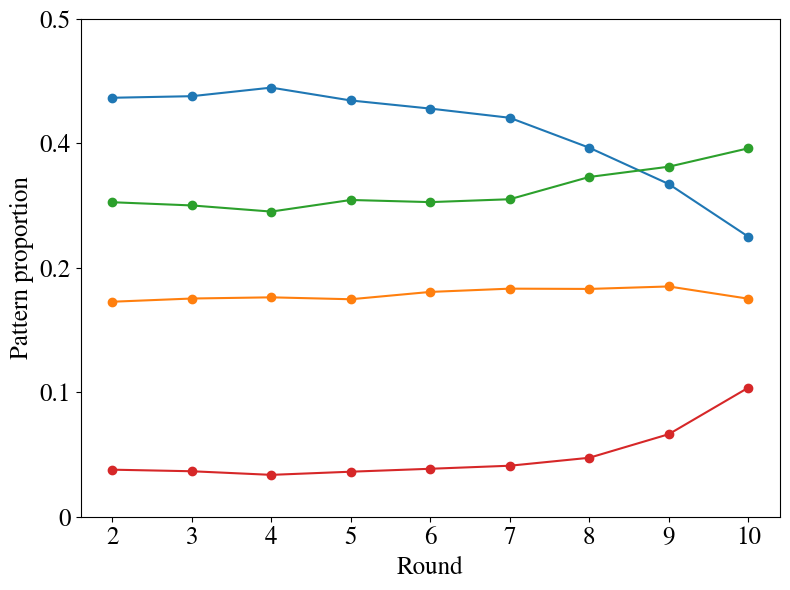

0.4414244336402193
30


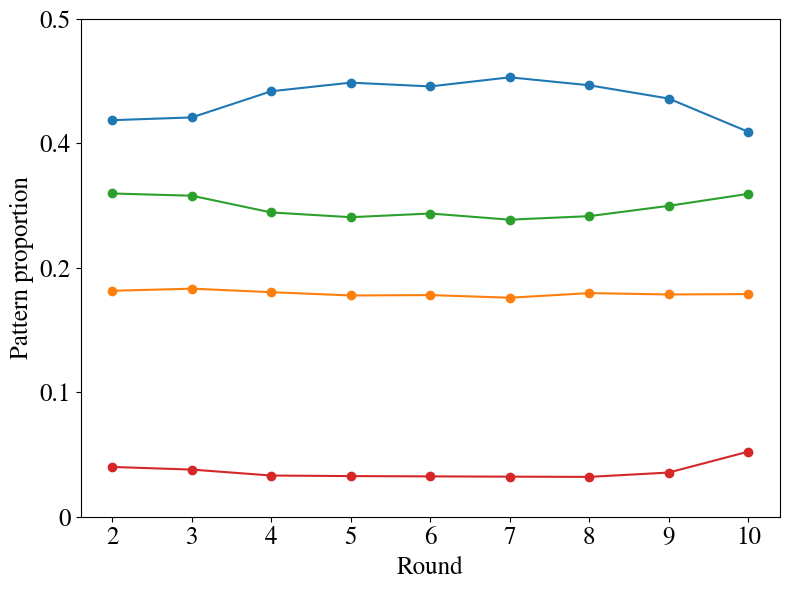

0.4287039901020724
40


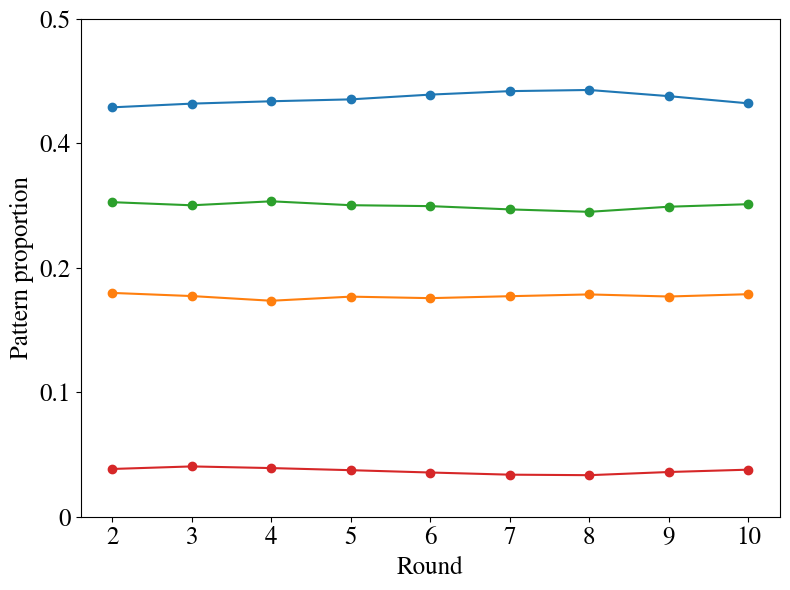

0.4461939284096058
48


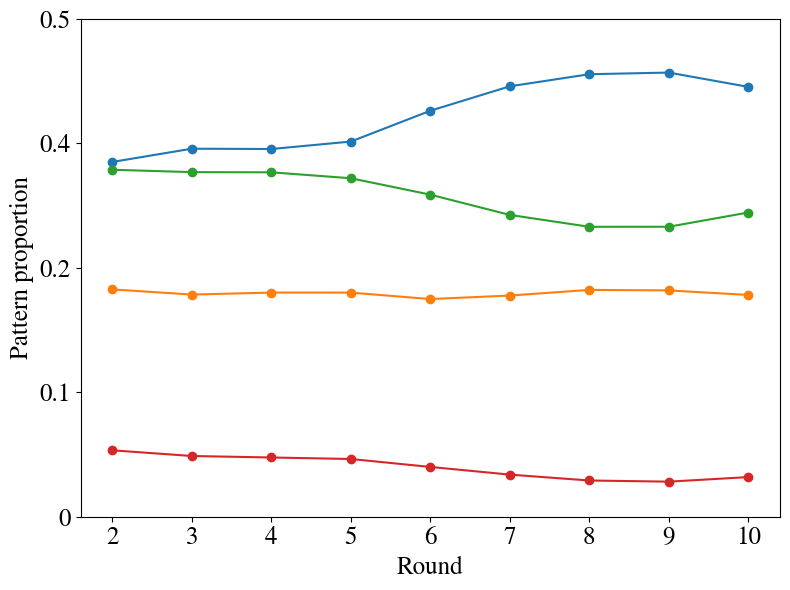

0.43498500051722355
60


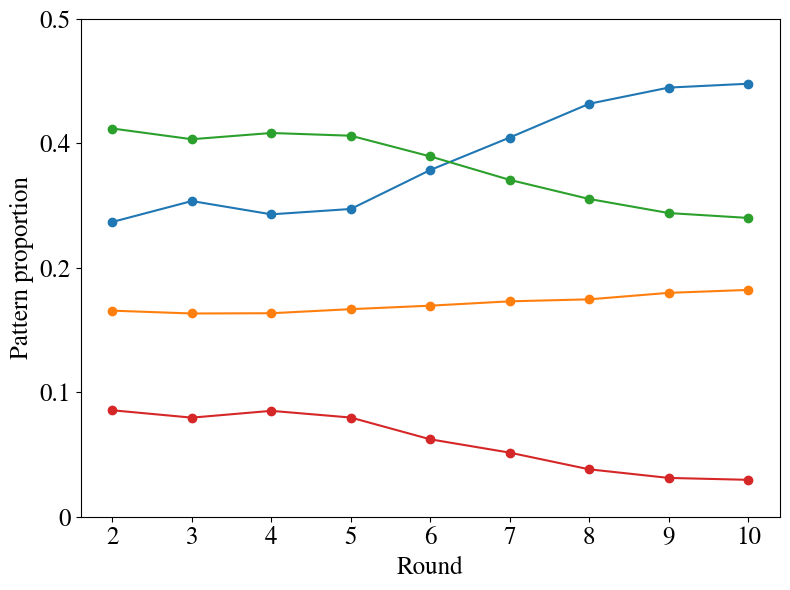

In [23]:
for endow, dsub in df.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"]=dsub["round"]+1
    counts = dsub.groupby(["round", "pattern_id"]).size()

    props = (
        (counts / counts.groupby(level="round").transform("sum"))
        .unstack(fill_value=0)
        .sort_index(axis=1)
    )

    print(props.max().max())
    props.plot(marker="o", figsize=(8,6), legend=False)
    plt.ylabel("Pattern proportion", fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2,11))

    # Round up to nearest 0.1
    ymax = props.max().max()
    ymax_rounded = math.ceil(ymax * 10) / 10  

    # Create 5 ticks
    yticks = np.linspace(0, ymax_rounded, 5)

    # Apply limits
    plt.ylim(0, ymax_rounded)

    # Format: 0 as "0", rest as one decimal
    ytick_labels = ["0" if y == 0 else f"{y:.1f}" for y in yticks]
    plt.yticks(yticks, ytick_labels)
    plt.tight_layout()
    plt.savefig(f"{output_folder}/PatternRoundSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()

Temporal evolution of pattern proportions in unsuccessful games

0.4398464163822526
24


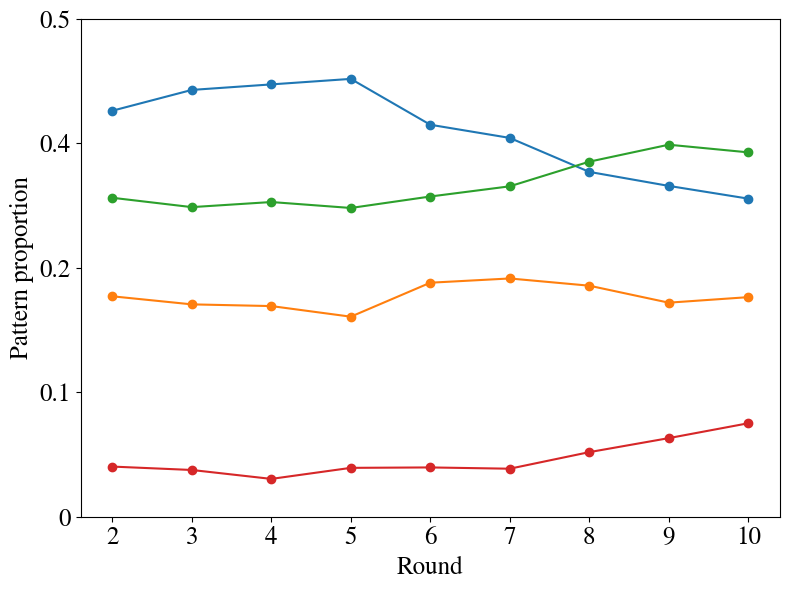

0.4692192192192192
30


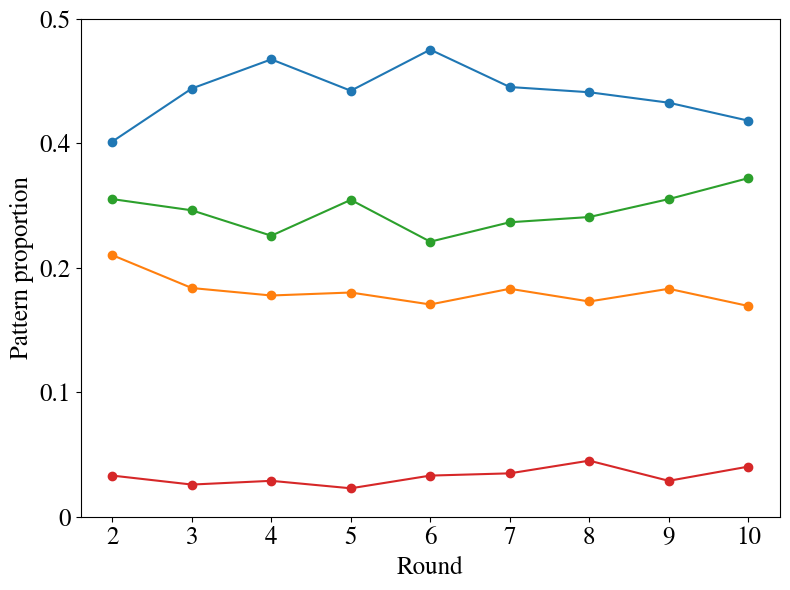

0.482281284606866
40


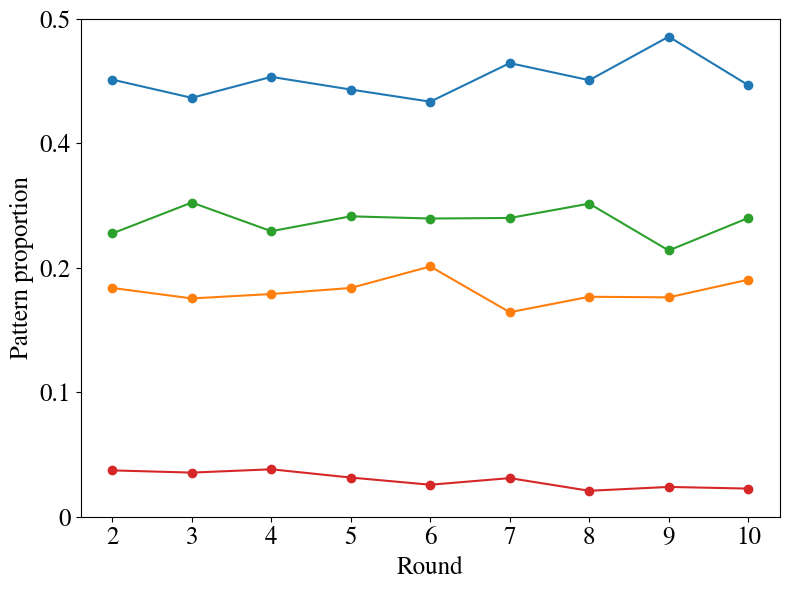

0.45371160409556316
48


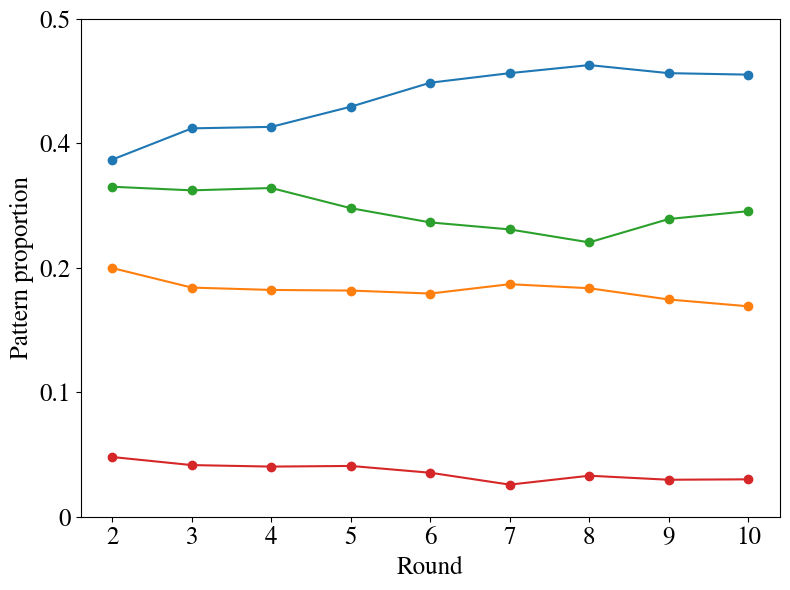

0.44894894894894893
60


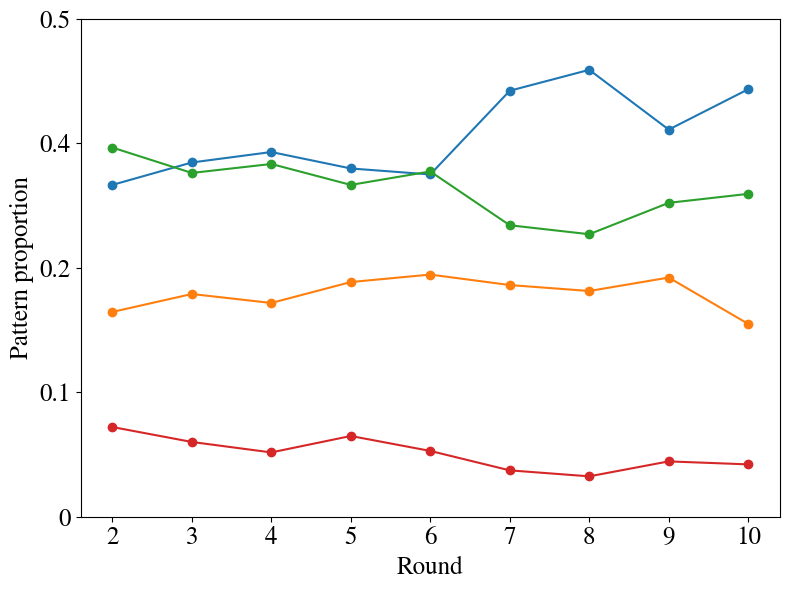

In [24]:
for endow, dsub in df_un.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"]=dsub["round"]+1
    counts = dsub.groupby(["round", "pattern_id"]).size()

    props = (
        (counts / counts.groupby(level="round").transform("sum"))
        .unstack(fill_value=0)
        .sort_index(axis=1)
    )

    print(props.max().max())
    props.plot(marker="o", figsize=(8,6), legend=False)
    plt.ylabel("Pattern proportion", fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2,11))

    # Round up to nearest 0.1
    ymax = props.max().max()
    ymax_rounded = math.ceil(ymax * 10) / 10  

    # Create 5 ticks
    yticks = np.linspace(0, ymax_rounded, 5)

    # Apply limits
    plt.ylim(0, ymax_rounded)

    # Format: 0 as "0", rest as one decimal
    ytick_labels = ["0" if y == 0 else f"{y:.1f}" for y in yticks]
    plt.yticks(yticks, ytick_labels)
    plt.tight_layout()
    plt.savefig(f"{output_folder}/PatternRoundUNSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()

Temporal evolution of pattern proportions under random in successful games

In [25]:
theoretical_probs_pattern = {
    4: 3/81,
    3: 24/81,
    2: 18/81,
    1: 36/81
}

24


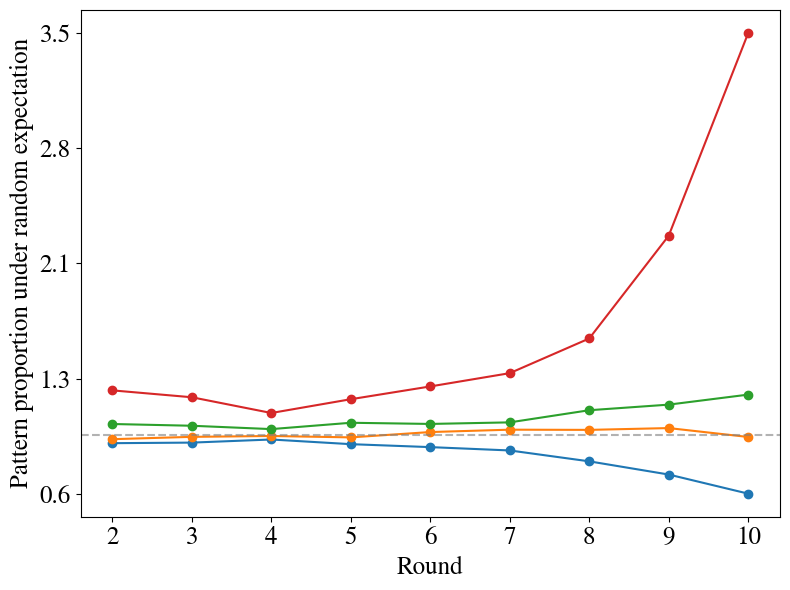

30


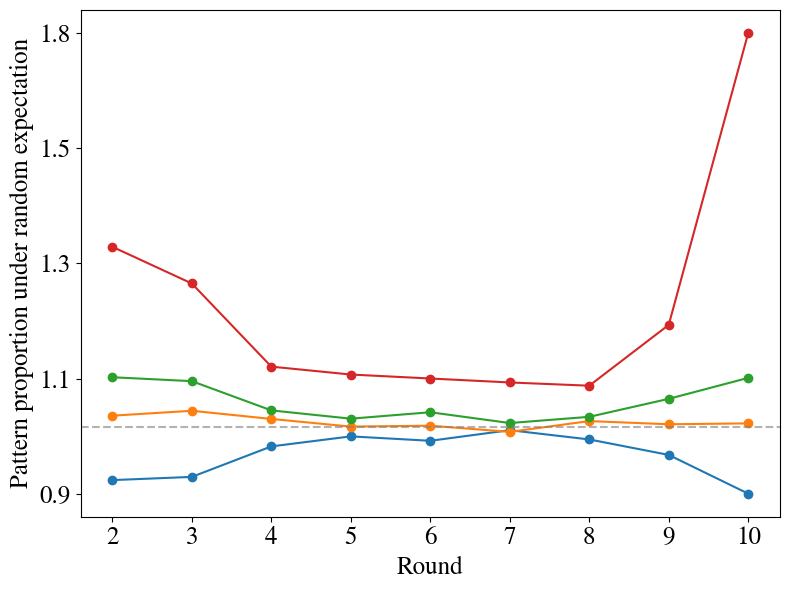

40


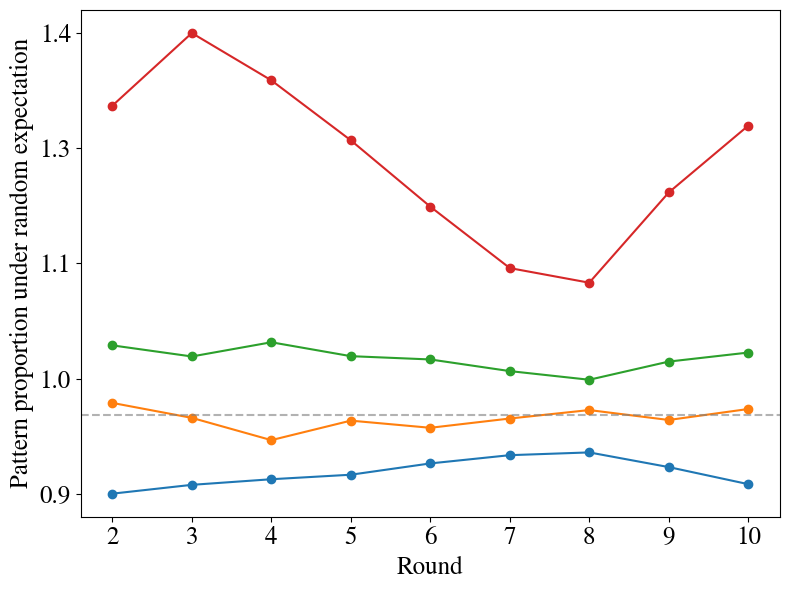

48


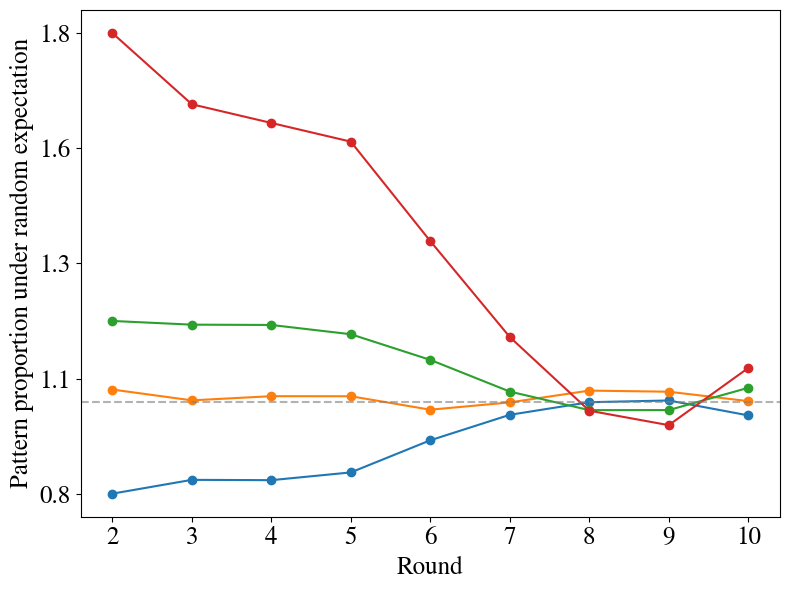

60


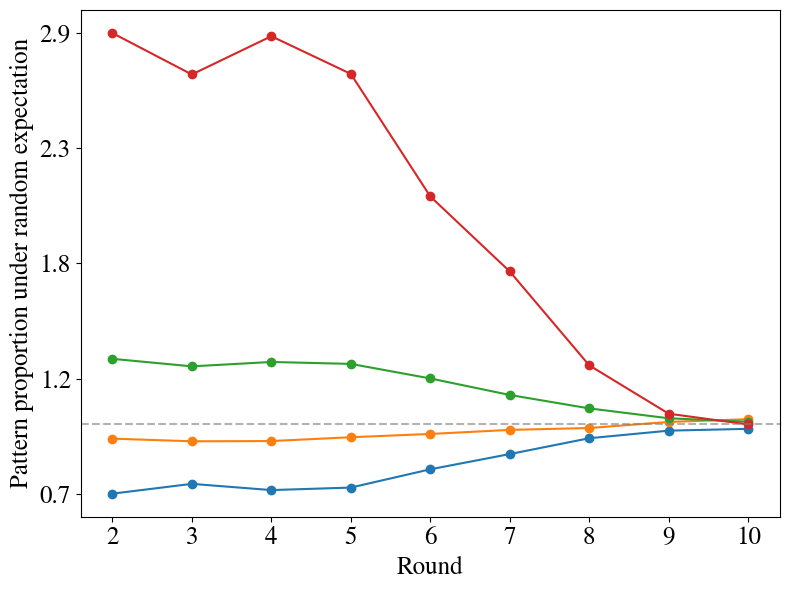

In [26]:
for endow, dsub in df.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"] = dsub["round"] + 1
    counts = dsub.groupby(["round", "pattern_id"]).size()

    props = (
        (counts / counts.groupby(level="round").transform("sum"))
        .unstack(fill_value=0)
        .sort_index(axis=1)
    )

    for col in props.columns:
        if col in theoretical_probs_pattern:
            props[col] = props[col] / theoretical_probs_pattern[col]

    props.plot(marker="o", figsize=(8,6), legend=False)

    # Round up to nearest 0.1
    ymax = props.max().max()
    ymax_rounded = math.ceil(ymax * 10) / 10  

    # Round up to nearest 0.1
    ymin = props.min().min()
    ymin_rounded = math.ceil(ymin * 10) / 10  

    # Create 5 ticks
    yticks = np.linspace(ymin, ymax, 5)

    # Format: 0 as "0", rest as one decimal
    ytick_labels = [f"{y:.1f}" for y in yticks]
    plt.yticks(yticks, ytick_labels)
    plt.axhline(1, color="gray", linestyle="--", alpha=0.6)
    plt.ylabel("Pattern proportion under random expectation",fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2, 11))
    plt.tight_layout()
    plt.savefig(f"{output_folder}/PatternRoundRandomSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()

Temporal evolution of pattern proportions under random in unsuccessful games

24


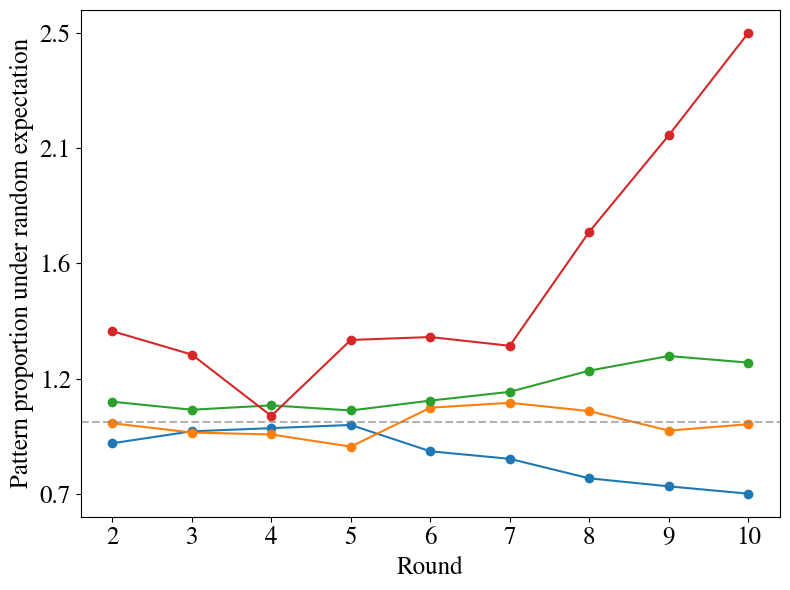

30


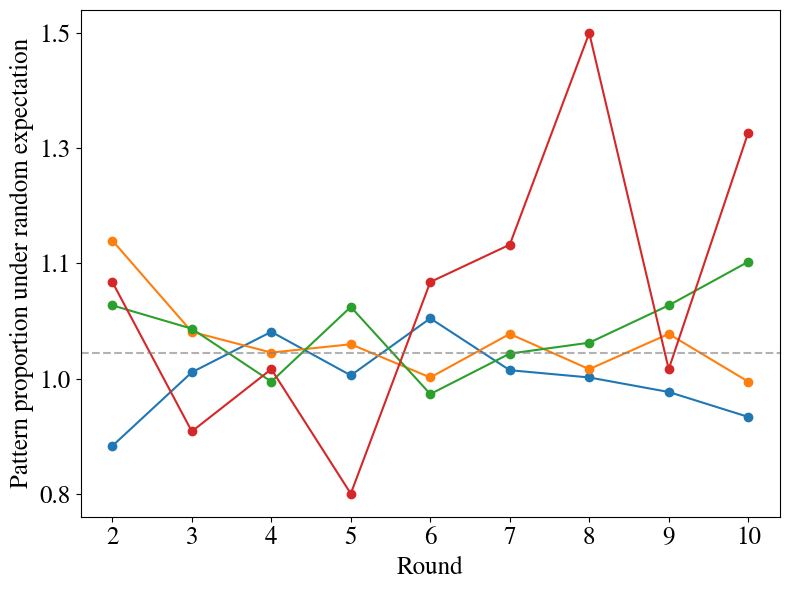

40


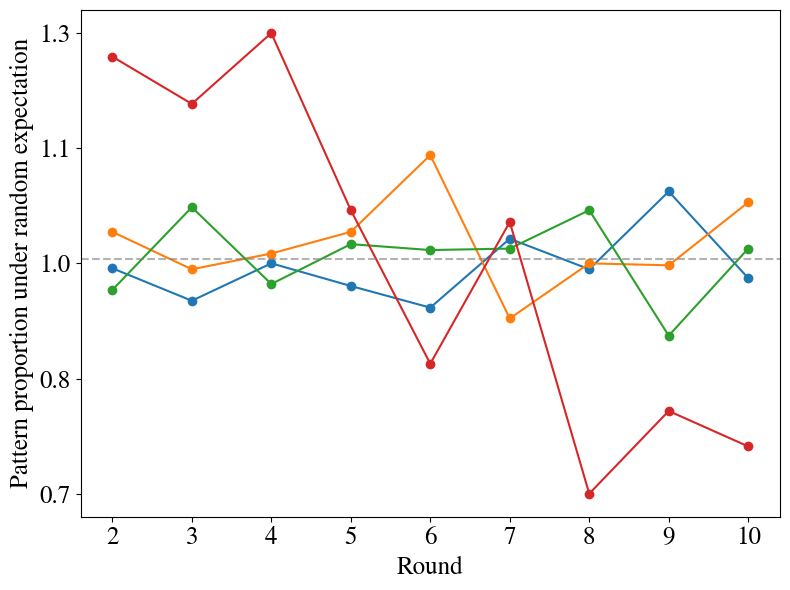

48


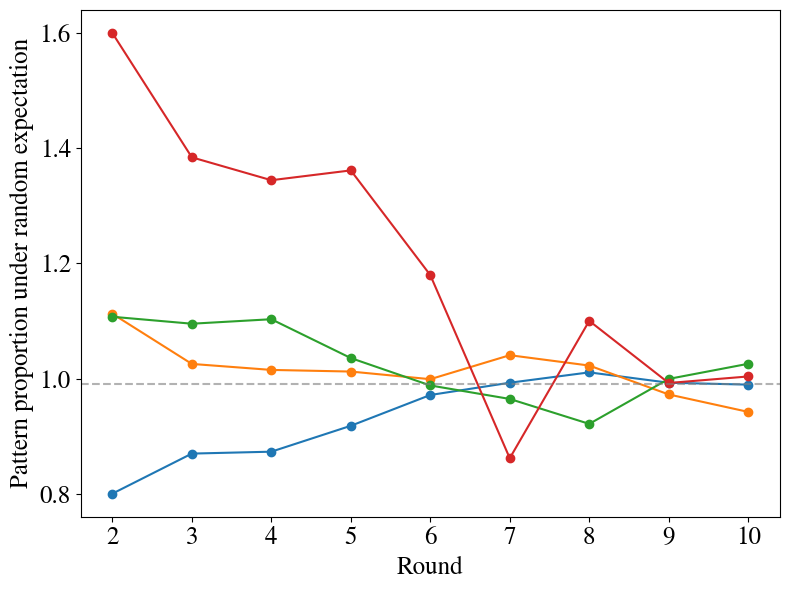

60


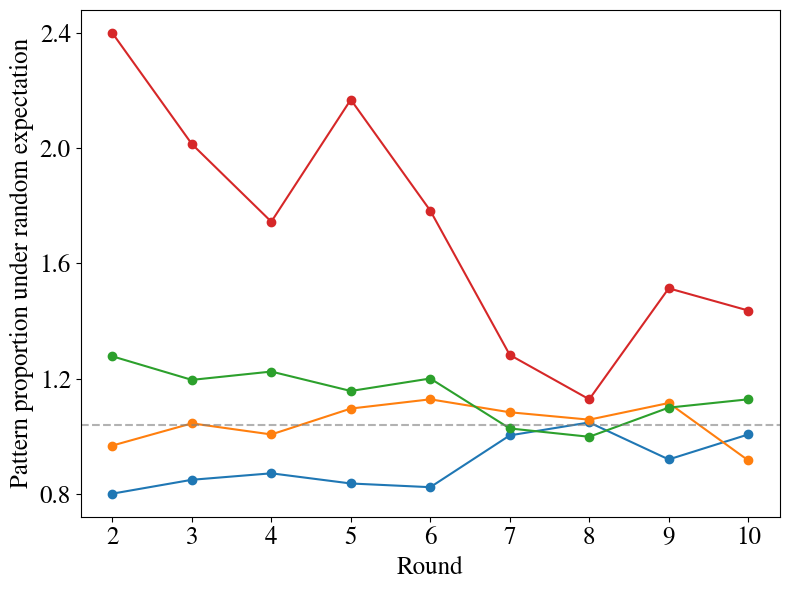

In [27]:
for endow, dsub in df_un.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"] = dsub["round"] + 1
    counts = dsub.groupby(["round", "pattern_id"]).size()
    
    props = (
        (counts / counts.groupby(level="round").transform("sum"))
        .unstack(fill_value=0)
        .sort_index(axis=1)
    )

    for col in props.columns:
        if col in theoretical_probs_pattern:
            props[col] = props[col] / theoretical_probs_pattern[col]

    props.plot(marker="o", figsize=(8,6), legend=False)

    # Round up to nearest 0.1
    ymax = props.max().max()
    ymax_rounded = math.ceil(ymax * 10) / 10  

    # Round up to nearest 0.1
    ymin = props.min().min()
    ymin_rounded = math.ceil(ymin * 10) / 10  

    # Create 5 ticks
    yticks = np.linspace(ymin, ymax, 5)

    # Format: 0 as "0", rest as one decimal
    ytick_labels = [f"{y:.1f}" for y in yticks]
    plt.yticks(yticks, ytick_labels)
    plt.axhline(1, color="gray", linestyle="--", alpha=0.6)
    plt.ylabel("Pattern proportion under random expectation",fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2, 11))
    plt.tight_layout()
    plt.savefig(f"{output_folder}/PatternRoundRandomUNSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()

Temporal evolution of average contributions in successful games

24


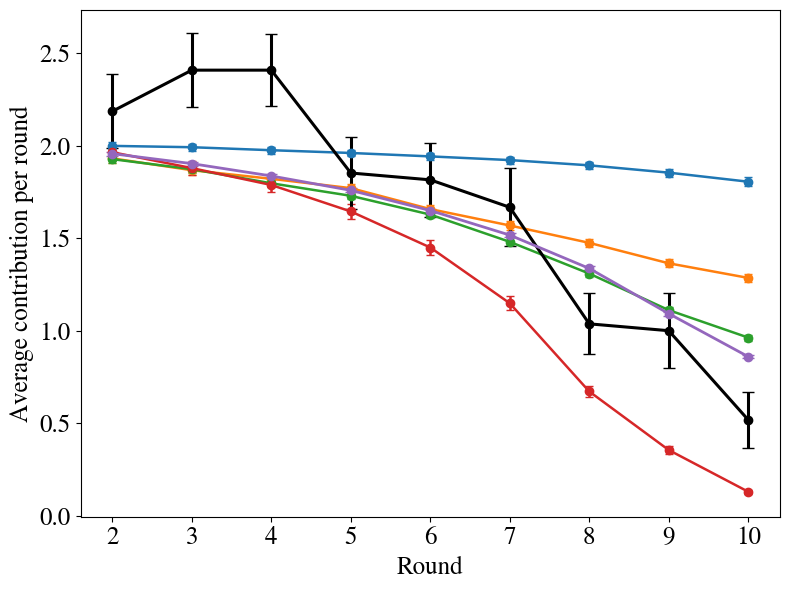

30


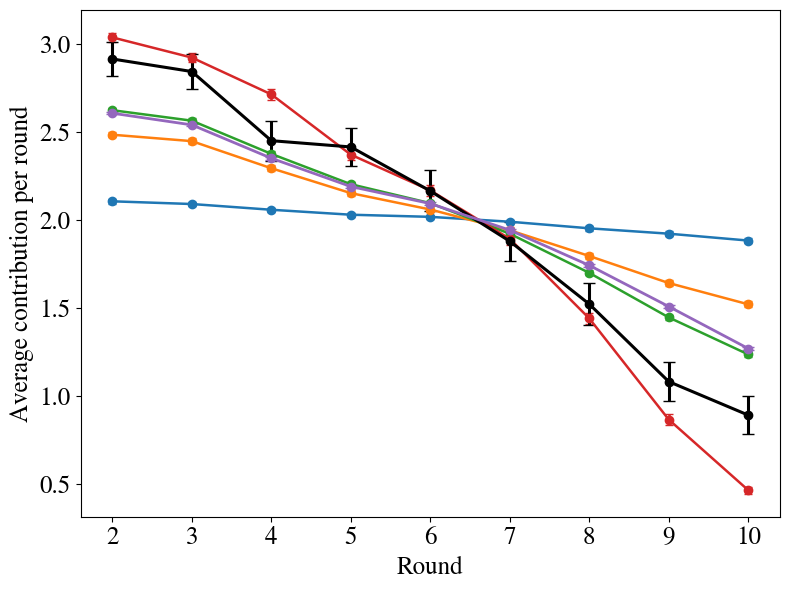

40


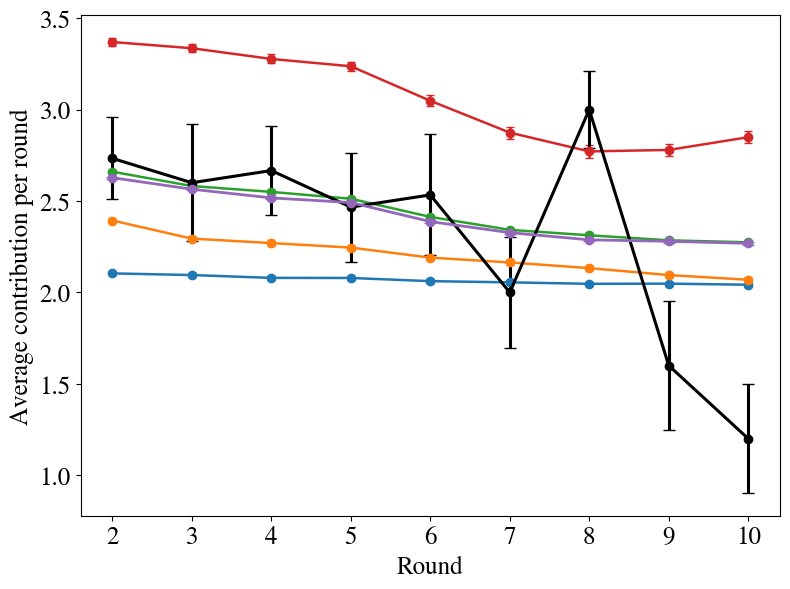

48


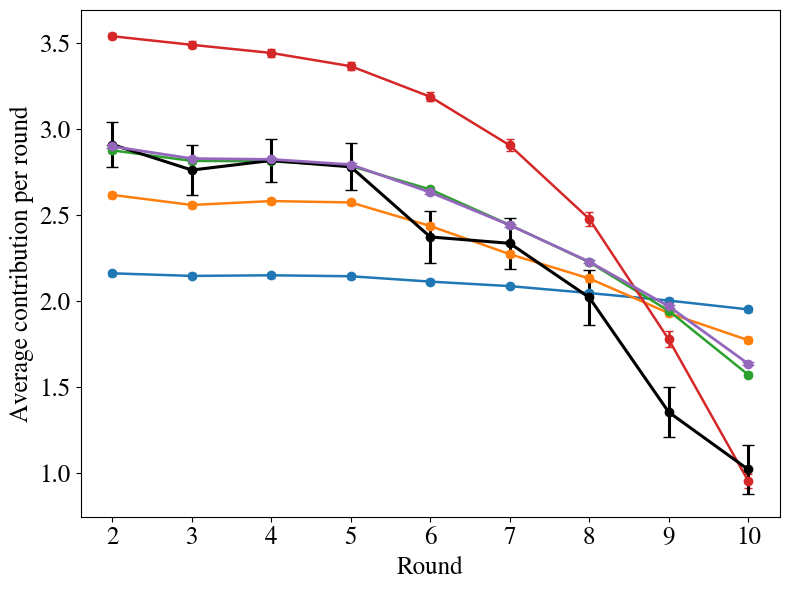

60


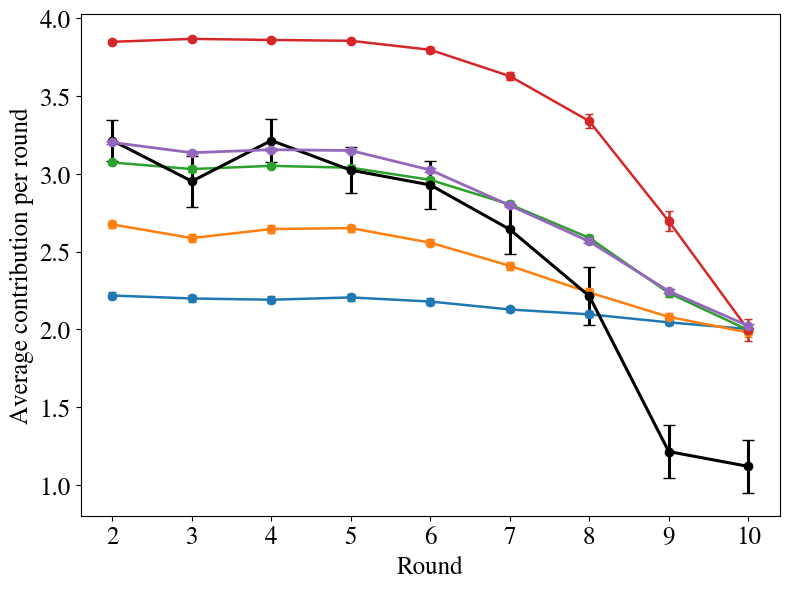

In [32]:
round_columns = [f'R{i}' for i in range(2, 11)]
df_users_rounds = successful_users_six[['endowment_initial'] + round_columns]
df_users_syn    = successful[['endowment_initial'] + round_columns]

# Empirical (real) means + SEM across users
mean_contributions = df_users_rounds.groupby('endowment_initial').mean()
sem_contributions  = df_users_rounds.groupby('endowment_initial').sem()

# Synthetic (final decided) means + SEM across users
mean_contributions_syn = df_users_syn.groupby('endowment_initial').mean()
sem_contributions_syn  = df_users_syn.groupby('endowment_initial').sem()

# Plotting with propagated errors
for endow, dsub in df.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"] = dsub["round"] + 1  # align simulated rounds 1–9 -> 2–10

    # Build mean ± propagated error for each (round, pattern_id)
    agg = (dsub
           .groupby(["round", "pattern_id"])
           .apply(lambda g: pd.Series({
               "mean_of_means": g["mean"].mean(),
               "err_total":     propagated_plus_sem(g["std"].values, g["mean"].values),
               "n":             len(g)
           }))
           .reset_index())

    # Pivot for plotting multiple pattern_id series with errors
    rounds = sorted(agg["round"].unique())
    pattern_ids = sorted(agg["pattern_id"].unique())

    plt.figure(figsize=(8,6))

    # plot mean_by_entropy with error bars per pattern_id
    for pid in pattern_ids:
        sub = agg[agg["pattern_id"] == pid].sort_values("round")
        plt.errorbar(
            sub["round"], sub["mean_of_means"],
            yerr=sub["err_total"],
            marker="o", capsize=3, lw=1.8,
            label=f"pattern {pid}"
        )

    # add empirical (real) curve: mean ± SEM
    means = mean_contributions.loc[endow]
    sems  = sem_contributions.loc[endow]
    plt.errorbar(
        x=range(2, 11),
        y=means, yerr=sems,
        marker='o', capsize=4, color='black', lw=2.2,
        label=f'Empirical mean (endowment {endow})'
    )

    # add synthetic (final) curve: mean ± SEM
    means_syn = mean_contributions_syn.loc[endow]
    sems_syn  = sem_contributions_syn.loc[endow]
    plt.errorbar(
        x=range(2, 11),
        y=means_syn, yerr=sems_syn,
        marker='o', capsize=4, lw=2.0, color='tab:purple',
        label=f'Synthetic mean (endowment {endow})'
    )

    plt.ylabel("Average contribution per round", fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2, 11))
    plt.tight_layout()
    plt.savefig(f"{output_folder}/AvcontribRoundSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()

Temporal evolution of average contributions in unsuccessful games

24


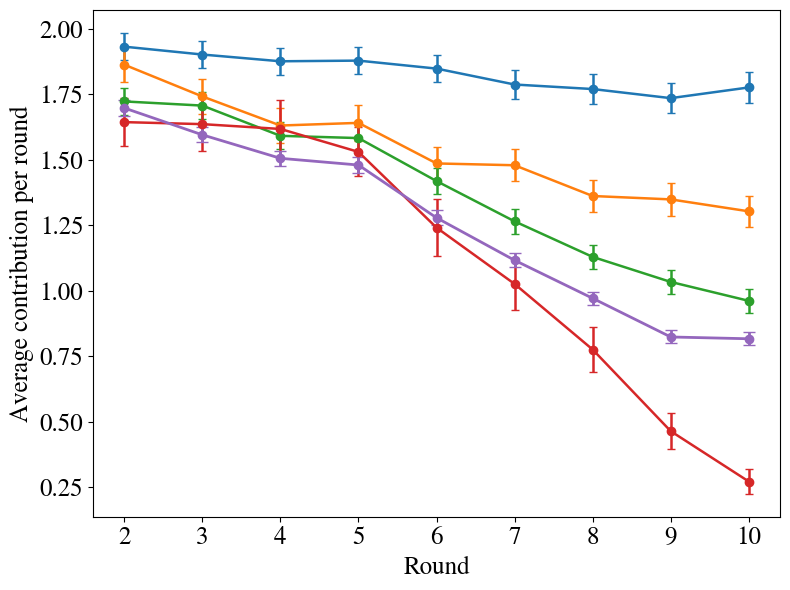

30


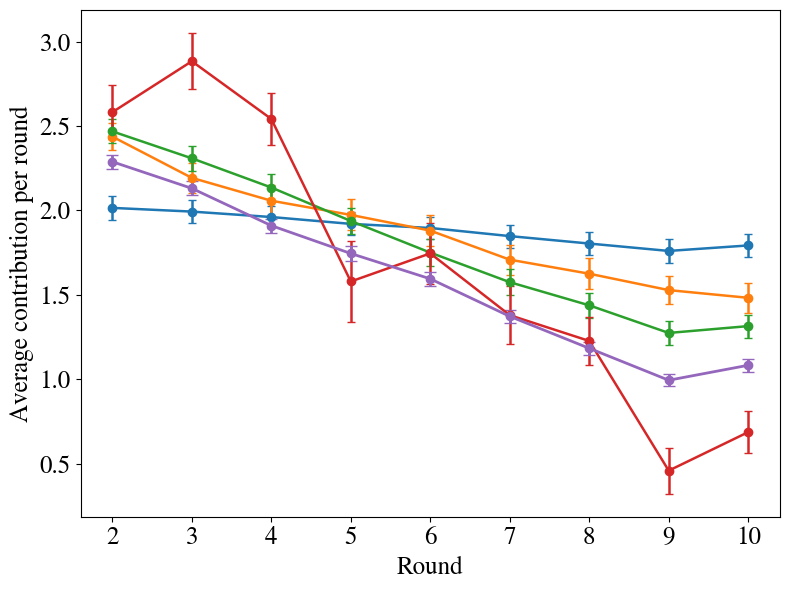

40


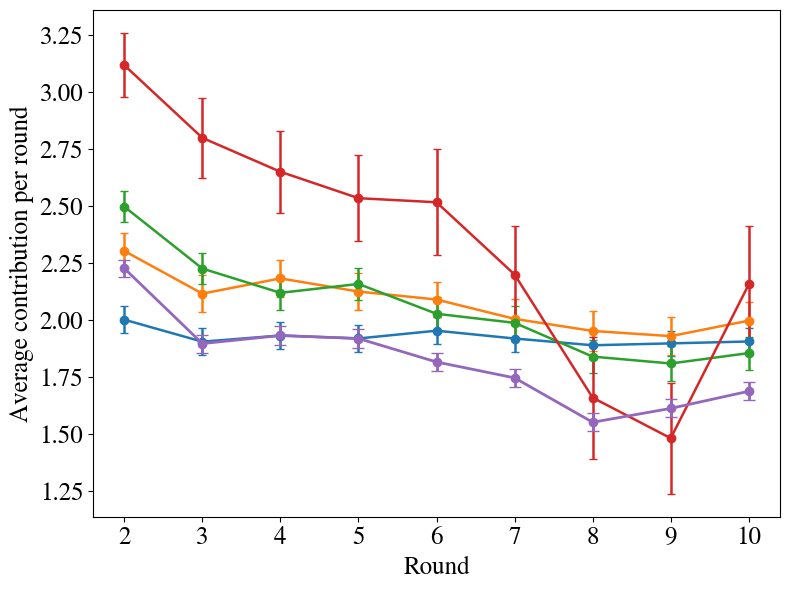

48


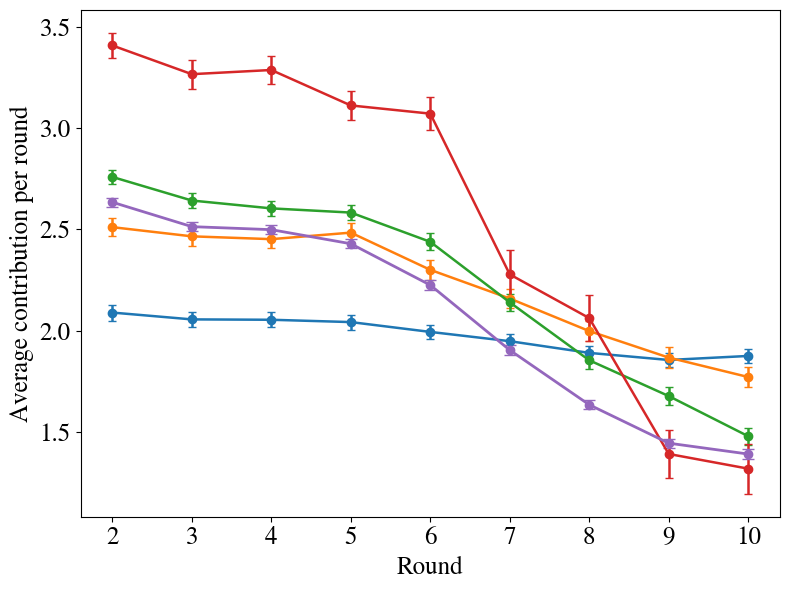

60


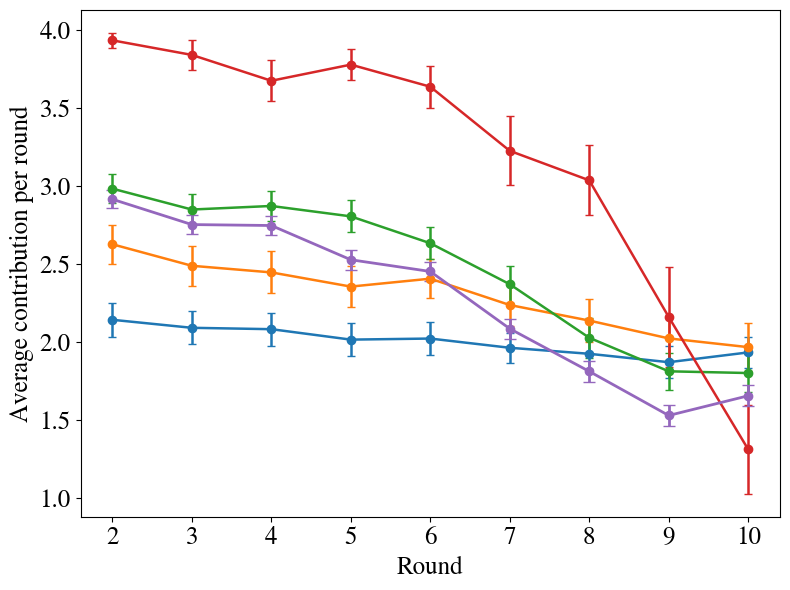

In [33]:
df_users_syn = unsuccessful[['endowment_initial'] + round_columns]

# Synthetic (final decided) means + SEM across users
mean_contributions_syn = df_users_syn.groupby('endowment_initial').mean()
sem_contributions_syn  = df_users_syn.groupby('endowment_initial').sem()

# Plotting with propagated errors
for endow, dsub in df_un.groupby("endowment"):
    dsub = dsub.copy()
    dsub["round"] = dsub["round"] + 1  # align simulated rounds 1–9 -> 2–10

    # Build mean ± propagated error for each (round, pattern_id)
    agg = (dsub
           .groupby(["round", "pattern_id"])
           .apply(lambda g: pd.Series({
               "mean_of_means": g["mean"].mean(),
               "err_total":     propagated_plus_sem(g["std"].values, g["mean"].values),
               "n":             len(g)
           }))
           .reset_index())

    # Pivot for plotting multiple pattern_id series with errors
    rounds = sorted(agg["round"].unique())
    pattern_ids = sorted(agg["pattern_id"].unique())

    plt.figure(figsize=(8,6))

    # plot mean_by_entropy with error bars per pattern_id
    for pid in pattern_ids:
        sub = agg[agg["pattern_id"] == pid].sort_values("round")
        plt.errorbar(
            sub["round"], sub["mean_of_means"],
            yerr=sub["err_total"],
            marker="o", capsize=3, lw=1.8,
            label=f"pattern {pid}"
        )

    # add synthetic (final) curve: mean ± SEM
    means_syn = mean_contributions_syn.loc[endow]
    sems_syn  = sem_contributions_syn.loc[endow]
    plt.errorbar(
        x=range(2, 11),
        y=means_syn, yerr=sems_syn,
        marker='o', capsize=4, lw=2.0, color='tab:purple',
        label=f'Synthetic mean (endowment {endow})'
    )

    plt.ylabel("Average contribution per round", fontsize=18)
    plt.xlabel("Round", fontsize=18)
    plt.tick_params(labelcolor='black', labelsize=18)
    plt.xticks(range(2, 11))
    plt.tight_layout()
    plt.savefig(f"{output_folder}/AvcontribRoundUNSUCCES_{endow}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(endow)
    plt.show()